# 03 — Análise Epidemiológica
**Objetivo:** Caracterizar o perfil das vítimas e correlacionar variáveis clínicas com desfecho.

Análises:
- Perfil demográfico das vítimas
- Distribuição de doses por grupo de exposição
- Correlação dose × desfecho clínico
- Evolução temporal dos casos


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

df = pd.read_csv("../data/processed/vitimas_clean.csv")
dosimetria = pd.read_csv("../data/processed/dosimetria_clean.csv")

print(f"Vítimas: {len(df)} | Internados: {df['internado'].sum()} | Óbitos: {df['obito'].sum()}")


Vítimas: 249 | Internados: 57 | Óbitos: 4


## 3.1 — Perfil Demográfico

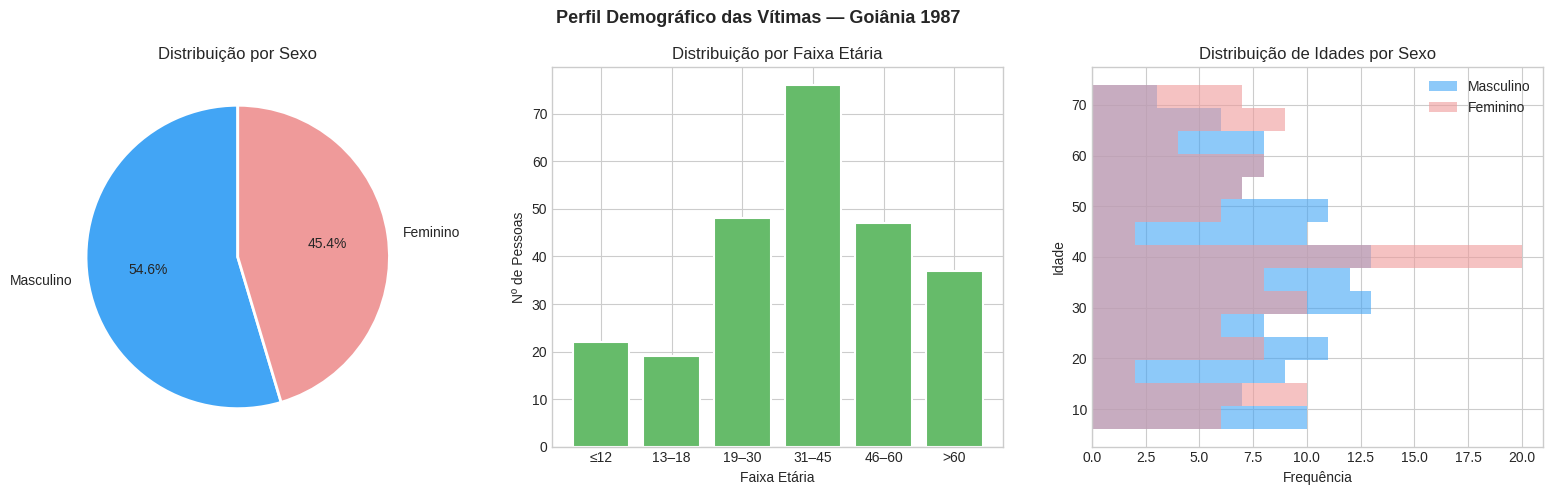

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Perfil Demográfico das Vítimas — Goiânia 1987", fontsize=13, fontweight='bold')

# Sexo
sexo_counts = df['sexo'].value_counts()
colors_pie = ['#42A5F5', '#EF9A9A']
axes[0].pie(sexo_counts, labels=['Masculino', 'Feminino'], autopct='%1.1f%%',
            startangle=90, colors=colors_pie, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Distribuição por Sexo")

# Faixa etária
df['faixa_etaria'] = pd.cut(df['idade'],
    bins=[0, 12, 18, 30, 45, 60, 100],
    labels=['≤12', '13–18', '19–30', '31–45', '46–60', '>60'])
faixa_counts = df['faixa_etaria'].value_counts().sort_index()
axes[1].bar(faixa_counts.index.astype(str), faixa_counts.values,
            color='#66BB6A', edgecolor='white', linewidth=1.5)
axes[1].set_title("Distribuição por Faixa Etária")
axes[1].set_xlabel("Faixa Etária")
axes[1].set_ylabel("Nº de Pessoas")

# Pirâmide etária simplificada
masc = df[df['sexo'] == 'M']['idade']
fem = df[df['sexo'] == 'F']['idade']
axes[2].hist(masc, bins=15, alpha=0.6, color='#42A5F5', label='Masculino', orientation='horizontal')
axes[2].hist(fem, bins=15, alpha=0.6, color='#EF9A9A', label='Feminino', orientation='horizontal')
axes[2].set_title("Distribuição de Idades por Sexo")
axes[2].set_xlabel("Frequência")
axes[2].set_ylabel("Idade")
axes[2].legend()

plt.tight_layout()
plt.savefig("../reports/figures/03_perfil_demografico.png", dpi=150, bbox_inches='tight')
plt.show()


## 3.2 — Distribuição de Doses por Grupo

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribuição de Doses por Grupo de Exposição", fontsize=13, fontweight='bold')

cores_grupo = {'leve': '#66BB6A', 'moderado': '#FFA726', 'alto': '#EF5350'}

# Boxplot
grupos_order = ['leve', 'moderado', 'alto']
data_plot = [df[df['grupo_exposicao'] == g]['dose_mSv'].values for g in grupos_order]
bp = axes[0].boxplot(data_plot, labels=['Leve
(n=200)', 'Moderado
(n=36)', 'Alto
(n=13)'],
                     patch_artist=True, notch=False)
colors = ['#A5D6A7', '#FFCC80', '#EF9A9A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_yscale('log')
axes[0].set_ylabel("Dose (mSv) — escala log")
axes[0].set_title("Boxplot de Doses por Grupo")
axes[0].axhline(y=1000, color='red', linestyle='--', alpha=0.5, label='1000 mSv (síndrome grave)')
axes[0].axhline(y=100, color='orange', linestyle='--', alpha=0.5, label='100 mSv (síndrome leve)')
axes[0].legend(fontsize=8)

# Internação e óbito por categoria de dose
df['categoria_dose'] = pd.cut(df['dose_mSv'],
    bins=[0, 50, 200, 1000, 10001],
    labels=['< 50', '50–200', '200–1000', '> 1000'])
cat_internado = df.groupby('categoria_dose', observed=True)['internado'].mean() * 100
cat_obito = df.groupby('categoria_dose', observed=True)['obito'].mean() * 100

x = np.arange(len(cat_internado))
width = 0.35
axes[1].bar(x - width/2, cat_internado.values, width, label='% Internado', color='#42A5F5', alpha=0.8)
axes[1].bar(x + width/2, cat_obito.values, width, label='% Óbito', color='#EF5350', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_internado.index)
axes[1].set_ylabel("Percentual (%)")
axes[1].set_title("Internação e Óbito por Categoria de Dose")
axes[1].set_xlabel("Dose (mSv)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/03_doses_por_grupo.png", dpi=150, bbox_inches='tight')
plt.show()


SyntaxError: unterminated string literal (detected at line 9) (2036165184.py, line 9)

## 3.3 — Correlação Dose × Desfecho Clínico

In [ ]:
from scipy.stats import pointbiserialr, chi2_contingency

# Correlação dose-internação
corr_intern, p_intern = pointbiserialr(df['dose_mSv'], df['internado'])
corr_obito, p_obito = pointbiserialr(df['dose_mSv'], df['obito'])

print("=== CORRELAÇÕES DOSE × DESFECHO ===")
print(f"Dose × Internação: r = {corr_intern:.3f}, p = {p_intern:.4e}")
print(f"Dose × Óbito:      r = {corr_obito:.3f}, p = {p_obito:.4e}")

# Teste qui-quadrado: sexo × internação
contingencia = pd.crosstab(df['sexo'], df['internado'])
chi2, p_chi, dof, _ = chi2_contingency(contingencia)
print(f"\nQui-Quadrado (Sexo × Internação): χ² = {chi2:.3f}, p = {p_chi:.4f}")
print("(p > 0.05: sexo não é fator de risco significativo para internação)")

# Scatter dose vs dias
fig, ax = plt.subplots(figsize=(10, 5))
cores = df['obito'].map({0: '#42A5F5', 1: '#EF5350'})
ax.scatter(np.log10(df['dose_mSv'] + 1), df['dias_desfecho'],
           c=cores, alpha=0.6, s=40, edgecolors='white', linewidths=0.5)
patch_vivo = mpatches.Patch(color='#42A5F5', label='Sobreviveu')
patch_obito = mpatches.Patch(color='#EF5350', label='Óbito')
ax.legend(handles=[patch_vivo, patch_obito])
ax.set_xlabel("log₁₀(Dose em mSv)")
ax.set_ylabel("Dias até Desfecho (ou censura)")
ax.set_title("Dose vs. Tempo até Desfecho")
plt.tight_layout()
plt.savefig("../reports/figures/03_dose_vs_desfecho.png", dpi=150, bbox_inches='tight')
plt.show()


## 3.4 — Síndrome Aguda de Radiação (SAR)

In [ ]:
# Classificação por SAR baseada nas doses (protocolo AIEA)
def classificar_sar(dose):
    if dose < 100:   return "Sem SAR"
    elif dose < 500: return "SAR Grau I (Leve)"
    elif dose < 2000:return "SAR Grau II (Moderada)"
    else:            return "SAR Grau III/IV (Grave)"

df['sar'] = df['dose_mSv'].apply(classificar_sar)

sar_counts = df['sar'].value_counts()
print("=== CLASSIFICAÇÃO SAR ===")
print(sar_counts)
print(f"\nTotal com alguma SAR: {(df['sar'] != 'Sem SAR').sum()} pessoas ({(df['sar'] != 'Sem SAR').mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
cores_sar = ['#A5D6A7', '#FFCC80', '#EF9A9A', '#B71C1C']
sar_order = ['Sem SAR', 'SAR Grau I (Leve)', 'SAR Grau II (Moderada)', 'SAR Grau III/IV (Grave)']
valores = [sar_counts.get(s, 0) for s in sar_order]
bars = ax.barh(sar_order, valores, color=cores_sar, edgecolor='white')
for bar, val in zip(bars, valores):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10)
ax.set_xlabel("Nº de Pessoas")
ax.set_title("Distribuição da Síndrome Aguda de Radiação (SAR)")
ax.set_xlim(0, max(valores) * 1.15)
plt.tight_layout()
plt.savefig("../reports/figures/03_sar.png", dpi=150, bbox_inches='tight')
plt.show()

df.to_csv("../data/processed/vitimas_clean.csv", index=False)
print("\n✅ Dados atualizados com coluna 'sar' exportados")
